# NEB Input Generation — Edge Dislocation ⟨111⟩{110} in Fe

This notebook generates, minimizes, and aligns the **initial** and **final** endpoint configurations  
for a Nudged Elastic Band (NEB) calculation of edge dislocation glide in BCC iron.

**Pipeline:**
1. Generate dislocation structures with Atomsk  
2. Assign mobile / fixed atom types  
3. Two-stage LAMMPS minimization (FIRE → CG)  
4. Re-align via KDTree + MIC unwrapping  
5. Export NEB-ready `.config` files  
6. Format final endpoint for LAMMPS NEB  
7. Assemble case directory & write LAMMPS NEB input script

## 1 · Environment Setup & Directory Initialisation

In [1]:
import os
import numpy as np
from pathlib import Path
import shutil, subprocess
import matplotlib.pyplot as plt

# Simulation & Geometry Tools
from lammps import lammps
from ase import Atoms
from ase.io import read, write
from ase.geometry import find_mic
from scipy.spatial import cKDTree

# --- Directory Management ---
base_dir = Path.cwd().parent
input_dir = base_dir / "input"
neb_dir   = input_dir / "neb_input"

# Clear existing input directory to prevent file conflicts
if input_dir.exists():
    shutil.rmtree(input_dir)

# Recreate fresh directories
input_dir.mkdir(parents=True, exist_ok=True)
neb_dir.mkdir(parents=True, exist_ok=True)

potential_file = base_dir / "potentials/mendelev03.fs"
print(f"Directory cleared. Working in: {input_dir}")
print(f"Potential:  {potential_file}")
print(f"NEB output: {neb_dir}")

Directory cleared. Working in: /home/Ethan/Projects/glide_neb/input
Potential:  /home/Ethan/Projects/glide_neb/potentials/mendelev03.fs
NEB output: /home/Ethan/Projects/glide_neb/input/neb_input


## 2 · Generate Dislocation Structures (Atomsk)

Creates two BCC Fe supercells with an edge dislocation inserted at:
- **Initial**: `X_INI`  
- **Final**: `X_INI + Burgers vector` (one glide step)

Crystal orientation: **[111] || X**, **[1-10] || Y**, **[11-2] || Z**

In [ ]:
# --- Configuration ---
LAT_PARAM    = 2.8665          # BCC Fe lattice parameter (Å)
X_SIZE, Y_SIZE, Z_SIZE = 70, 50, 3
BURG_VECT    = 2.4825          # Burgers vector magnitude (Å)
POISSON_RATIO = 0.33

# Dislocation X-positions
X_INI = 10.0
X_FIN = X_INI + BURG_VECT*3
Y_POS = "0.51*box"             # Atomsk relative coordinate

# --- Execution ---
configs = {
    "ini": input_dir / "Fe_edge_111_110_ini.lmp",
    "fin": input_dir / "Fe_edge_111_110_fin_1.lmp"
}

for key, pos_x in [("ini", X_INI), ("fin", X_FIN)]:
    print(f"Generating {key} configuration at X={pos_x:.4f} Å ...")
    subprocess.run([
        "atomsk", "--create", "bcc", str(LAT_PARAM), "Fe",
        "orient", "[111]", "[1-10]", "[11-2]",
        "-duplicate", str(X_SIZE), str(Y_SIZE), str(Z_SIZE),
        "-dislocation", str(pos_x), Y_POS, "edge_add", "Z", "Y",
        str(BURG_VECT), str(POISSON_RATIO),
        str(configs[key])
    ], check=True)
    print(f"  → Written: {configs[key].name}")

print("\nDone.")

Generating ini configuration at X=10.0000 Å ...
 ___________________________________________________
|              ___________                          |
|     o---o    A T O M S K                          |
|    o---o|    Version master-2025-10-28 (Beta)     |
|    |   |o    (C) 2010 Pierre Hirel                |
|    o---o     https://atomsk.univ-lille.fr         |
|___________________________________________________|
>>> Creating system:
..> Bcc Fe oriented X=[111], Y=[1-10], Z=[11-2].
..> System was successfully created.
>>> Duplicating the system: 70 x 50 x 3
..> System was successfully duplicated (63000 atoms).
>>> Inserting an edge dislocation with line along Z,
    by inserting a plane of atoms,
    b=[2.482 0.000 0.000] at (10.000,103.373)
..> 441 atoms were inserted.
..> Dislocation stresses were computed.
..> Prelogarithmic energy factor: b²/4pi(1-nu) = 0.61119575
..> Cell length was changed by +b/2 along X.
..> One dislocation was successfully inserted.
>>> Writing output 

## 3 · Assign Atom Types (Mobile / Fixed)

Atoms in the top and bottom `NUM_FIXED_LAYERS` layers are assigned **Type 2 ("Ru")** and  
will be frozen during minimization. All others are **Type 1 ("Fe")** and are free to relax.

> The "Ru" label is a LAMMPS grouping convention — there is no actual ruthenium.

In [3]:
TOTAL_Y_LAYERS  = int(Y_SIZE) * 2   # Layers in Y direction
NUM_FIXED_LAYERS = 6                 # Fixed layers top & bottom

typed_paths = []

for name, path in configs.items():
    atoms = read(str(path), format="lammps-data", atom_style="atomic")

    # 1. Sort atoms: X → Y → Z for consistency
    pos      = atoms.get_positions()
    sort_idx = np.lexsort((pos[:, 2], pos[:, 1], pos[:, 0]))
    atoms    = atoms[sort_idx].copy()
    atoms.center()

    # 2. Identify fixed boundary layers
    y_coords = atoms.get_positions()[:, 1]
    y_min, y_max = y_coords.min(), y_coords.max()
    y_height = y_max - y_min

    layer_thickness    = y_height / TOTAL_Y_LAYERS
    boundary_threshold = layer_thickness * NUM_FIXED_LAYERS

    fixed_mask = (
        (y_coords <= y_min + boundary_threshold + 0.01) |
        (y_coords >= y_max - boundary_threshold - 0.01)
    )

    # 3. Assign types
    new_types = np.ones(len(atoms), dtype=int)
    new_types[fixed_mask] = 2
    atoms.set_array('type', new_types)
    atoms.set_chemical_symbols(['Fe' if t == 1 else 'Ru' for t in new_types])
    atoms.set_pbc([True, False, True])

    # 4. Write
    out_path = input_dir / f"typed_{path.name}"
    write(str(out_path), atoms, format="lammps-data",
          specorder=["Fe", "Ru"], atom_style="atomic")
    typed_paths.append(out_path)

    n_mobile = int(np.sum(~fixed_mask))
    n_fixed  = int(np.sum(fixed_mask))
    print(f"{out_path.name}: {n_mobile} mobile (Type 1)  |  {n_fixed} fixed (Type 2)")

typed_Fe_edge_111_110_ini.lmp: 55827 mobile (Type 1)  |  7614 fixed (Type 2)
typed_Fe_edge_111_110_fin_1.lmp: 55827 mobile (Type 1)  |  7614 fixed (Type 2)


## 4 · Two-Stage LAMMPS Minimization

Each structure is relaxed using:
1. **FIRE** — fast initial convergence  
2. **CG** — fine convergence

Fixed atoms (`fixgrp`, Type 2) are held fully frozen via `setforce 0 0 0`.  
Per-atom stress, PE, and KE are exported to a verbose dump for post-analysis.

In [4]:
for file_path in typed_paths:
    min_data_path   = input_dir / file_path.name.replace("typed_", "minimized_")
    verbose_dump    = input_dir / file_path.name.replace("typed_", "verbose_").replace(".lmp", ".dump")

    print(f"\nMinimizing: {file_path.name}")
    lmp = lammps()
    try:
        cmds = [
            "units metal", "dimension 3", "boundary p s p",
            "atom_style atomic", "atom_modify map yes",
            f"read_data {file_path}",

            # Potential
            "pair_style eam/fs",
            f"pair_coeff * * {potential_file} Fe Fe",

            # Freeze boundary atoms completely
            "group fixgrp type 2",
            "fix 1 fixgrp setforce NULL 0.0 NULL",

            # Per-atom computes
            "compute stress all stress/atom NULL",
            "compute peatom all pe/atom",
            "compute keatom all ke/atom",

            # Stage 1: FIRE
            "min_style fire",
            "minimize 1.0e-6 1.0e-8 1000 10000",

            # Stage 2: CG
            "min_style cg",
            "minimize 1.0e-8 1.0e-10 5000 10000",

            # Standard dump (unwrapped coords)
            f"write_dump all custom {min_data_path} id type xu yu zu",

            # Verbose dump
            (f"write_dump all custom {verbose_dump} id type xu yu zu "
             "c_stress[1] c_stress[2] c_stress[3] c_stress[4] c_stress[5] c_stress[6] "
             "c_peatom c_keatom"),
        ]
        for c in cmds:
            lmp.command(c)
        print(f"  ✓ Minimized → {min_data_path.name}")
        print(f"  ✓ Verbose   → {verbose_dump.name}")
    except Exception as e:
        print(f"  ✗ Error: {e}")
    finally:
        lmp.close()


Minimizing: typed_Fe_edge_111_110_ini.lmp
LAMMPS (22 Jul 2025)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread.
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (175.01358 202.69216 21.064387)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  63441 atoms
  read_data CPU = 0.124 seconds
7614 atoms in group fixgrp
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 7.3
  ghost atom cutoff = 7.3
  binsize = 3.65, bins = 48 56 6
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair eam/fs, perpetual
      attributes: half, newton on
      pair build: half/bin/atomonly/newton
      stencil: half/bin/3d
      bin: standard
Setting up fire style minimization ...
  Unit style    : metal
  Current step  : 0
  Parameters for fire:
    dmax  delaystep dtgrow dtshrink alpha0 alphashrink tmax tmin   integrator   halfstep

## 5 · Align Minimized Structures (KDTree + MIC)

After minimization, atom ordering may differ between initial and final structures.  
This cell:
- Uses a **KDTree** to map final → initial atom order  
- Applies **minimum image convention (MIC)** to recover correct glide displacements  
  (avoids periodic-boundary artefacts)

In [5]:
# 1. Load minimized structures
ini_atoms = read(str(input_dir / "minimized_Fe_edge_111_110_ini.lmp"), format="lammps-dump-text")
fin_atoms = read(str(input_dir / "minimized_Fe_edge_111_110_fin_1.lmp"), format="lammps-dump-text")

# 2. Extract Dynamic Box dimensions
current_cell = ini_atoms.get_cell()
lx, ly, lz = current_cell[0,0], current_cell[1,1], current_cell[2,2]

# 3. Topological Sorting (Initial)
# Ensures atoms are indexed predictably (X -> Y -> Z)
pos_ini = ini_atoms.get_positions()
sort_idx = np.lexsort((pos_ini[:, 2], pos_ini[:, 1], pos_ini[:, 0]))
ini_atoms = ini_atoms[sort_idx].copy()

# 4. Center and Define Three Regions
ini_atoms.set_cell(current_cell)
ini_atoms.center(vacuum=0, axis=1)

# Calculate layers based on previous notebook settings
TOTAL_Y_LAYERS = int(Y_SIZE) * 2 
NUM_FIXED_LAYERS = 4

y_coords_ini = ini_atoms.get_positions()[:, 1]
y_min, y_max = y_coords_ini.min(), y_coords_ini.max()
y_height = y_max - y_min
layer_thickness = y_height / TOTAL_Y_LAYERS
boundary_threshold = layer_thickness * NUM_FIXED_LAYERS

# Identify indices for the three distinct regions
# Type 2: Bottom Slab | Type 3: Top Slab | Type 1: Everything else (Mobile)
bottom_fixed_idx = np.where(y_coords_ini <= y_min + boundary_threshold + 0.01)[0]
top_fixed_idx = np.where(y_coords_ini >= y_max - boundary_threshold - 0.01)[0]

# 5. KDTree Mapping (Using Dynamic Box)
fin_atoms.set_cell(current_cell)
fin_atoms.set_pbc([True, False, True])
fin_atoms.wrap()

# Map fin_atoms to the sorted ini_atoms indices
tree = cKDTree(fin_atoms.get_positions(), boxsize=[lx, 0, lz]) 
_, mapping_indices = tree.query(ini_atoms.get_positions())
fin_atoms = fin_atoms[mapping_indices].copy()

# 6. MIC Unwrapping
# Fixes periodic boundary jumps to reflect true atomic glide
dr = fin_atoms.get_positions() - ini_atoms.get_positions()
dr_mic, _ = find_mic(dr, current_cell, [True, False, True])
fin_atoms.set_positions(ini_atoms.get_positions() + dr_mic)

# 7. Final Assignment and Export
processed_paths = []
for atoms, name in zip([ini_atoms, fin_atoms], ["initial.config", "final.config"]):
    # Initialize all as Type 1 (Mobile Fe)
    new_types = np.ones(len(atoms), dtype=int)
    
    # Assign Slab types
    new_types[bottom_fixed_idx] = 2  # Bottom Slab
    new_types[top_fixed_idx] = 3     # Top Slab
    
    atoms.set_array('type', new_types)
    atoms.set_array('id', np.arange(1, len(atoms) + 1))
    
    # All atoms are Fe, regardless of type ID
    atoms.set_chemical_symbols(['Fe'] * len(atoms))
    atoms.set_masses([55.845] * len(atoms))
    
    # Standardize cell and PBC
    atoms.set_cell(current_cell)
    atoms.set_pbc([True, False, True])
    atoms.center(vacuum=0, axis=1)

    out_path = neb_dir / name
    # Exporting as lammps-data with 3 atom types defined
    write(str(out_path), atoms, format='lammps-data', 
          specorder=['Fe', 'Fe', 'Fe'], atom_style='atomic')
    processed_paths.append(out_path)

print(f"Successfully aligned via dynamic cell: {lx:.2f} x {ly:.2f} x {lz:.2f}")
print(f"Regions defined: Type 1 (Mobile), Type 2 ({len(bottom_fixed_idx)} Bottom), Type 3 ({len(top_fixed_idx)} Top)")
print(f"Files ready in: {neb_dir}")

Successfully aligned via dynamic cell: 175.01 x 200.99 x 21.06
Regions defined: Type 1 (Mobile), Type 2 (2520 Bottom), Type 3 (2556 Top)
Files ready in: /home/Ethan/Projects/glide_neb/input/neb_input


## 6 · Visualise Displacements

Sanity-check the endpoint alignment:
- **Left**: spatial map coloured by displacement magnitude  
- **Right**: displacement vs atom ID

Max displacement : 0.4184 Å
Mean displacement: 0.0185 Å
Atoms displaced > 0.5 Å: 0


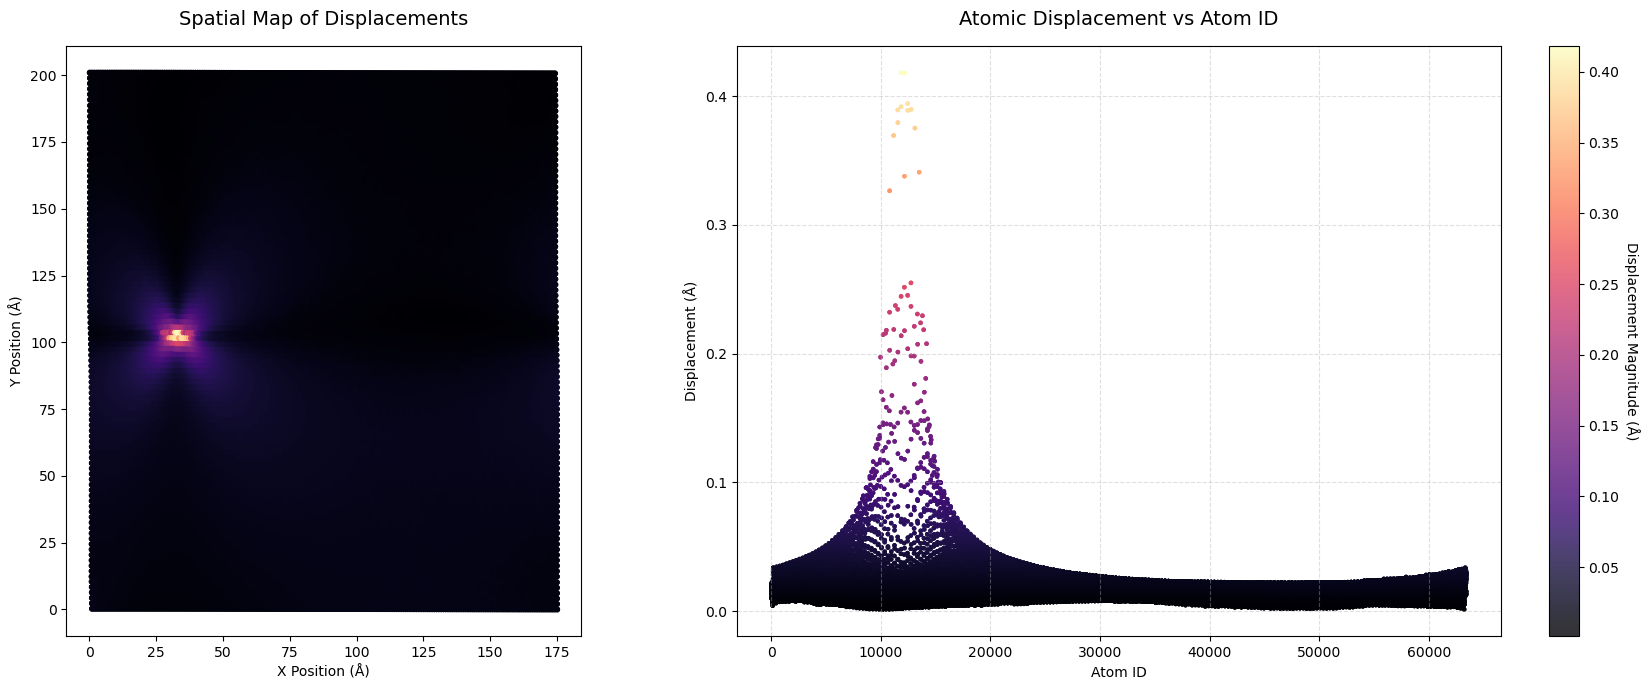

Figure saved → displacement_map.png


In [9]:
import matplotlib.pyplot as plt

# 1. Calculate displacements
# 'fin_atoms' must be reordered and MIC-corrected relative to 'ini_atoms'
diffs = fin_atoms.get_positions() - ini_atoms.get_positions()
displacements = np.linalg.norm(diffs, axis=1)
atom_ids = ini_atoms.get_array('id')

# 2. Setup Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.2]})

# --- Left Plot: Spatial Map (X-Y Plane) ---
sc1 = ax1.scatter(ini_atoms.positions[:, 0], ini_atoms.positions[:, 1], 
                  c=displacements, cmap='magma', s=10, alpha=0.8)
ax1.set_title("Spatial Map of Displacements", fontsize=14, pad=15)
ax1.set_xlabel("X Position (Å)")
ax1.set_ylabel("Y Position (Å)")
ax1.set_aspect('equal')

# --- Right Plot: Displacement vs Atom ID ---
# Removed the Burgers vector line to prevent Y-axis skewing
sc2 = ax2.scatter(atom_ids, displacements, c=displacements, cmap='magma', alpha=0.8, s=5)
ax2.set_title('Atomic Displacement vs Atom ID', fontsize=14, pad=15)
ax2.set_xlabel('Atom ID')
ax2.set_ylabel('Displacement (Å)')
ax2.grid(True, linestyle='--', alpha=0.4)

# Colorbar for the right plot
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('Displacement Magnitude (Å)', rotation=270, labelpad=15)

# Quick stats
print(f"Max displacement : {displacements.max():.4f} Å")
print(f"Mean displacement: {displacements.mean():.4f} Å")
print(f"Atoms displaced > 0.5 Å: {np.sum(displacements > 0.5)}")

plt.tight_layout()
plt.savefig(str(input_dir / "displacement_map.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → displacement_map.png")

## 7 · Format Final Endpoint for LAMMPS NEB

LAMMPS NEB reads the final endpoint as a plain text file:
```
<N_atoms>
<id> <x> <y> <z>
...
```
This cell converts `final.config` to that format.

In [7]:
def convert_to_neb_format(input_path, output_path):
    """
    Convert a LAMMPS data file to the minimal NEB endpoint format:
        line 1  : number of atoms
        lines 2+: id x y z   (type column dropped)
    """
    output_lines = []
    n_atoms      = None
    reading_atoms = False

    with open(input_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Capture atom count from header
            if "atoms" in line and n_atoms is None:
                try:
                    n_atoms = int(line.split()[0])
                    output_lines.append(str(n_atoms))
                except (ValueError, IndexError):
                    continue

            # Detect start of Atoms section
            elif line.lower().startswith("atoms"):
                reading_atoms = True
                continue

            elif reading_atoms:
                if line.startswith("#"):
                    continue
                parts = line.split()
                if len(parts) >= 5:
                    # id type x y z  →  id x y z
                    output_lines.append(f"{parts[0]} {parts[2]} {parts[3]} {parts[4]}")

    with open(output_path, 'w') as f:
        f.write("\n".join(output_lines) + "\n")

    return output_path

final_config      = neb_dir / "final.config"
final_config_neb  = neb_dir / "final_form.config"

convert_to_neb_format(str(final_config), str(final_config_neb))

# Quick verification
with open(final_config_neb) as f:
    lines = f.readlines()

print(f"NEB final endpoint written: {final_config_neb.name}")
print(f"  Atom count (header) : {lines[0].strip()}")
print(f"  First atom line     : {lines[1].strip()}")
print(f"  Last  atom line     : {lines[-1].strip()}")
print(f"  Total lines (incl. header): {len(lines)}")

NEB final endpoint written: final_form.config
  Atom count (header) : 63441
  First atom line     : 1 0.12348400000000001 200.93175499999998 4.1904700000000012
  Last  atom line     : 63441 175.11800000000002 -5.773159728050814e-15 19.2212
  Total lines (incl. header): 63442


## 8 · Assemble Case Directory & Write LAMMPS NEB Script

Creates the final simulation directory layout and writes a ready-to-run  
`neb.in` LAMMPS input script.

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Note: Ensure base_dir, neb_dir, and potential_file are defined earlier in your notebook
case_dir       = base_dir / "case_edge_111_110"
# Renamed to match the folder name used in your desired LAMMPS script
case_neb_dir   = case_dir / "minimized_processed_data"

# Create directories (omitting 'potentials' since we aren't copying anymore)
for d in [case_dir, case_neb_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Copy NEB endpoint files to the local case directory
shutil.copy(neb_dir / "initial.config",    case_neb_dir / "initial.config")
shutil.copy(neb_dir / "final_form.config", case_neb_dir / "final_form.config")

# Calculate the relative path from the 'neb_case' folder to the potential file
# This converts '/home/.../potentials/malerba.fs' into '../potentials/malerba.fs'
rel_potential_path = os.path.relpath(potential_file, start=case_dir)

print(f"Endpoint configs copied to → {case_neb_dir}")
print(f"Potential referenced via relative path → {rel_potential_path}")

# ── Write LAMMPS NEB input script ─────────────────────────────────────────
# Note: We use double braces {{a}} so that LAMMPS sees ${a} instead of Python trying to format it
neb_script = f"""units metal
dimension 3
boundary p s p
atom_style atomic
atom_modify map array
atom_modify sort 0 0.0

read_data minimized_processed_data/initial.config
reset_timestep 0

pair_style eam/fs
pair_coeff * * {rel_potential_path} Fe Fe Fe

timestep 0.001
run_style verlet
variable a uloop 512

group nebgrp type 1
group fixgrp type 2 3

compute pe all pe/atom
compute ke all ke/atom
compute stress all stress/atom NULL
compute myt all temp
compute myp all pressure myt
compute com all com

compute nebpe nebgrp reduce sum c_pe
compute nebke nebgrp reduce sum c_ke
compute nebstressXX nebgrp reduce sum c_stress[1]
compute nebstressYY nebgrp reduce sum c_stress[2]
compute nebstressZZ nebgrp reduce sum c_stress[3]
compute nebstressXY nebgrp reduce sum c_stress[4]
compute nebstressYZ nebgrp reduce sum c_stress[5]
compute nebstressXZ nebgrp reduce sum c_stress[6]

fix 1 nebgrp neb 10.0
fix freeze fixgrp setforce 0.0 0.0 0.0

min_style quickmin
min_modify dmax 0.01

thermo_style custom step c_nebpe c_nebke c_nebstressXX c_nebstressYY c_nebstressZZ c_nebstressXY c_nebstressYZ c_nebstressXZ
thermo 100

dump 1 all custom 250000 snapshot_all.${{a}}.* id type x y z fx fy fz c_pe c_stress[1] c_stress[2] c_stress[3] c_stress[4] c_stress[5] c_stress[6]
dump 2 nebgrp custom 250000 snapshot_neb.${{a}}.* id type x y z fx fy fz c_pe c_stress[1] c_stress[2] c_stress[3] c_stress[4] c_stress[5] c_stress[6]

neb 0.0 1.0e-3 50000 250000 100 final minimized_processed_data/final_form.config
"""

script_path = case_dir / "in.lmp"
with open(script_path, 'w') as f:
    f.write(neb_script)

print(f"\nLAMMPS NEB script written → {script_path}")

Endpoint configs copied to → /home/Ethan/Projects/glide_neb/case_edge_111_110/minimized_processed_data
Potential referenced via relative path → ../potentials/mendelev03.fs

LAMMPS NEB script written → /home/Ethan/Projects/glide_neb/case_edge_111_110/in.lmp


## 9 · Write Slurm Script

Creates the slurm script in `in.sh` for submission to slurm on a HPC system.

In [ ]:
# ── Write LAMMPS NEB input script ─────────────────────────────────────────
# Note: We use double braces {{a}} so that LAMMPS sees ${a} instead of Python trying to format it
slurm_script = f"""#!/bin/bash
#SBATCH --job-name=NEB_{case_dir.name}
#SBATCH --mail-user=eledmunds1@sheffield.ac.uk
#SBATCH --time=06:00:00
#SBATCH --ntasks=256
#SBATCH --mem=64G
#SBATCH --cpus-per-task=1
#SBATCH --output=slurm-%j.out
#SBATCH --exclude=node092,node113,node029,node034

mkdir -p logs
mkdir -p screen
mkdir -p snapshot_all
mkdir -p snapshot_neb

# 1. Load modules
module use $HOME/modulefiles
module load atom_sims

# 2. Set OpenMP threads
export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

# 4. Run
srun --export=ALL lmp -partition ${{SLURM_NTASKS}}x1 -in in.lmp

mv screen.* screen/
mv snapshot_neb.* snapshot_neb/
mv snapshot_all.* snapshot_all/
mv log.* logs/
"""

script_path = case_dir / "in.sh"
with open(script_path, 'w') as f:
    f.write(slurm_script)

print(f"\nSLURM submission script written → {script_path}")

# Visualise the new clean layout
print("\n── Case directory layout ──────────────────────────────")
for p in sorted(case_dir.rglob("*")):
    rel = p.relative_to(case_dir)
    indent = "  " * (len(rel.parts) - 1)
    print(f"{indent}{'📁' if p.is_dir() else '📄'} {p.name}")


SLURM submission script written → /home/Ethan/Projects/glide_neb/case_edge_111_110/in.sh

── Case directory layout ──────────────────────────────
📄 in.lmp
📄 in.sh
📁 minimized_processed_data
  📄 final_form.config
  📄 initial.config


## 10 · Summary & Next Steps

| File | Description |
|------|-------------|
| `neb_input/initial.config` | Minimized initial dislocation position |
| `neb_input/final_form.config` | NEB-formatted final dislocation position (one Burgers vector step) |
| `neb.in` | LAMMPS NEB input script |
| `potentials/mendelev03.fs` | EAM/FS potential for Fe |

**To run the NEB calculation:**
```bash
mpirun -np <N_replicas> lmp -partition <N_replicas>x1 -in neb.in
```
Replace `<N_replicas>` with the number of NEB images (e.g. 8 or 16).

**Typical post-processing:**
- Plot energy along the NEB path to extract the Peierls barrier  
- Visualise transition state geometry in OVITO